# Choose Your Own Adventure Lab -- Breast Cancer Dataset


I selected the Breast Cancer Wisconsin dataset that ships with scikit learn. It has 569 rows and many numeric features measured from digitized images of a breast mass. The target is **diagnosis** and the values are encoded as 0 for malignant and 1 for benign. I exported a CSV with five features plus the target.

**Target**  
- `target` (0 or 1) and `target_label` (malignant or benign)

**Features used**  
- `mean radius`  
- `mean texture`  
- `mean perimeter`  
- `mean area`  
- `mean smoothness`



In [4]:

import pandas as pd
from pathlib import Path

csv_path = Path() / "breast_cancer_selected.csv"
df = pd.read_csv(csv_path)
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,target,target_label
0,17.99,10.38,122.80,1001.0,0.11840,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0,malignant



## Feature values and basic description

The features are continuous measurements. The table below shows min and max for each feature, and we list the two possible target values.


In [5]:

desc = df.describe().T[["min","max"]]
target_values = df["target_label"].unique().tolist()
desc, target_values


(                       min        max
 mean radius        6.98100    28.1100
 mean texture       9.71000    39.2800
 mean perimeter    43.79000   188.5000
 mean area        143.50000  2501.0000
 mean smoothness    0.05263     0.1634
 target             0.00000     1.0000,
 ['malignant', 'benign'])


## Preprocessing

The dataset has no missing values for the selected fields, so I use the values as they are. For each visualization I compare the distributions between malignant and benign cases.


In [6]:

import numpy as np
import matplotlib.pyplot as plt

def boxplot_feature(feature):
    m = df[df["target_label"]=="malignant"][feature].values
    b = df[df["target_label"]=="benign"][feature].values

    plt.figure()
    plt.boxplot([m, b], labels=["malignant", "benign"], showmeans=True)
    plt.title(f"{feature} vs diagnosis")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()


## mean radius vs target

C:\Users\Stephen\AppData\Local\Temp\ipykernel_33832\2712054921.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([m, b], labels=["malignant", "benign"], showmeans=True)


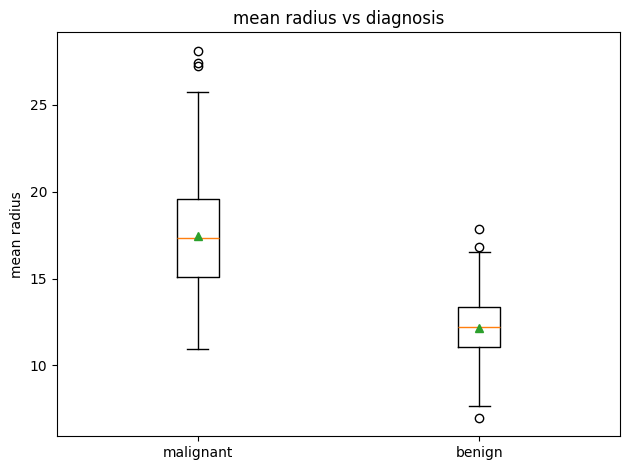

In [7]:
boxplot_feature('mean radius')

**Interpretation:** Larger mean radius values appear more common in malignant tumors. The distributions are well separated which suggests a strong relationship with the target.

## mean texture vs target

C:\Users\Stephen\AppData\Local\Temp\ipykernel_33832\2712054921.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([m, b], labels=["malignant", "benign"], showmeans=True)


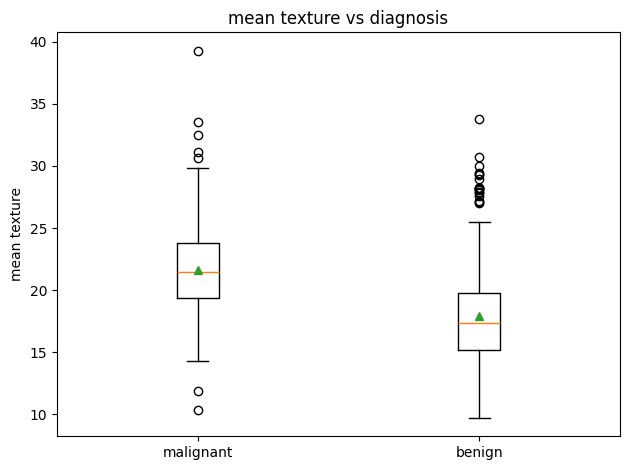

In [8]:
boxplot_feature('mean texture')

**Interpretation:** Mean texture overlaps more between classes than radius, but malignant cases tend to be slightly higher on average.

## mean perimeter vs target

C:\Users\Stephen\AppData\Local\Temp\ipykernel_33832\2712054921.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([m, b], labels=["malignant", "benign"], showmeans=True)


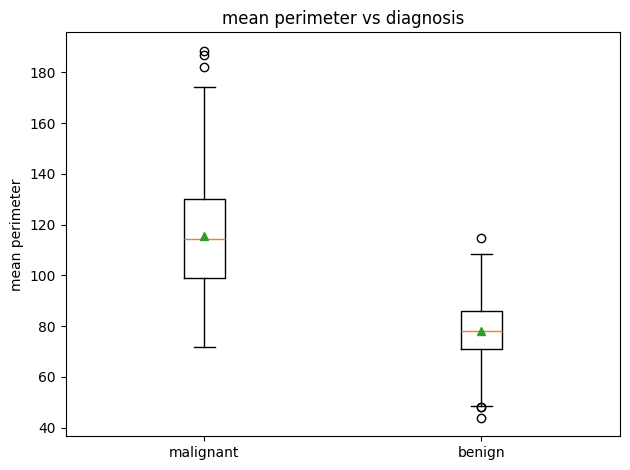

In [9]:
boxplot_feature('mean perimeter')

**Interpretation:** Mean perimeter shows a pattern similar to radius. Malignant tumors tend to have higher perimeter values which supports the idea that size relates to malignancy.

## mean area vs target

C:\Users\Stephen\AppData\Local\Temp\ipykernel_33832\2712054921.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([m, b], labels=["malignant", "benign"], showmeans=True)


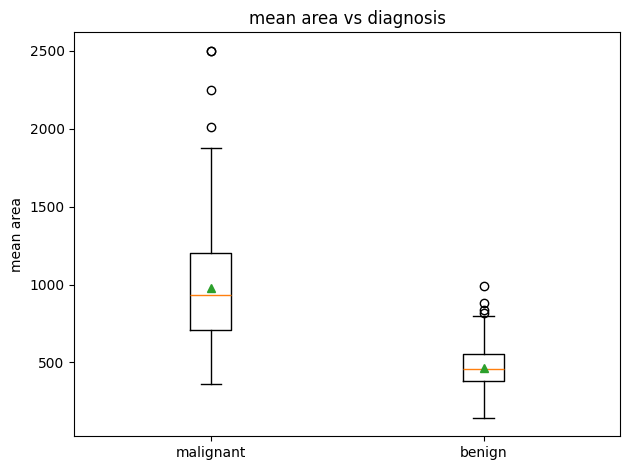

In [10]:
boxplot_feature('mean area')

**Interpretation:** Mean area is strongly associated with diagnosis. Malignant cases are higher on average and the spread is wide which is expected for a size based measurement.

## mean smoothness vs target

C:\Users\Stephen\AppData\Local\Temp\ipykernel_33832\2712054921.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([m, b], labels=["malignant", "benign"], showmeans=True)


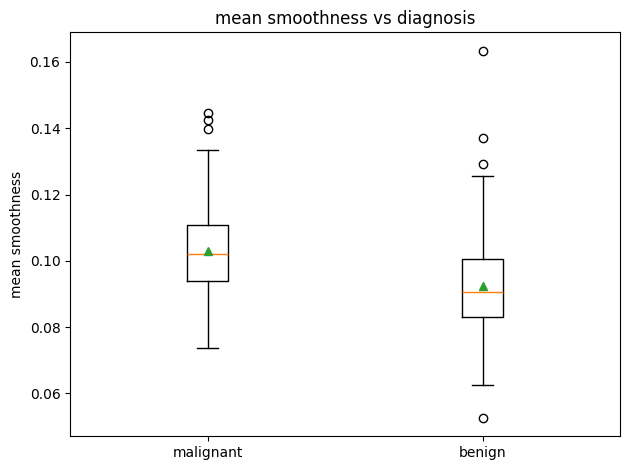

In [11]:
boxplot_feature('mean smoothness')

**Interpretation:** Mean smoothness differs by a smaller amount. There is overlap between classes which suggests smoothness alone is a weak predictor.


## Summary relationship strength

To get a quick numeric view I compute the absolute correlation between each feature and the binary target. Higher values suggest a stronger linear relationship with the target.


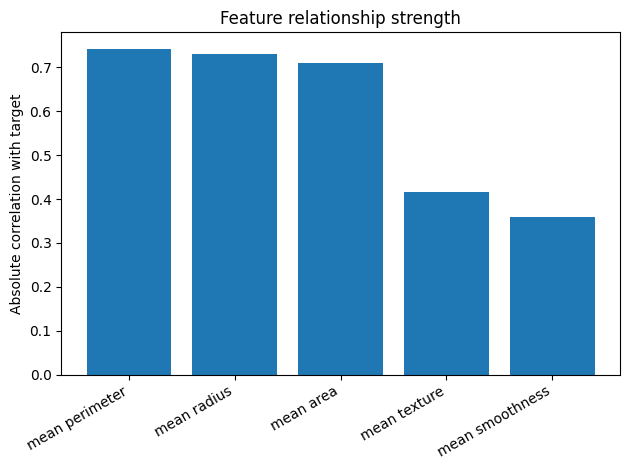

mean perimeter     0.742636
mean radius        0.730029
mean area          0.708984
mean texture       0.415185
mean smoothness    0.358560
Name: target, dtype: float64

In [12]:

features = ["mean radius","mean texture","mean perimeter","mean area","mean smoothness"]
corrs = df[features + ["target"]].corr(numeric_only=True)["target"].abs().drop("target").sort_values(ascending=False)

plt.figure()
x = np.arange(len(corrs))
plt.bar(x, corrs.values)
plt.xticks(x, corrs.index, rotation=30, ha="right")
plt.ylabel("Absolute correlation with target")
plt.title("Feature relationship strength")
plt.tight_layout()
plt.show()

corrs



## Big Picture Conclusion

Size related features like mean radius, mean perimeter, and mean area show the strongest relationships with diagnosis. Texture and smoothness matter, but they are not as strong on their own. The visual patterns match the numeric summary. In short, larger masses tend to be malignant in this dataset.
